## Saving a new SN object to the CAAT database

### Introduction

This notebook will demonstate how to instantiate a new `SN` object which does not already exist in the `CAAT` file, save its information to the `CAAT` file, and save its data for easy initialization later.

### Setup

First, let's create a dictionary containing fake data of a transient, as well as a dictionary of data in a few bands: 

In [1]:
from caat import SN

info = {
    "ra": 123.456,
    "dec": -43.21,
    "z": 0.015,
}

data = {
    "B": [
        {
            "mjd": 60500.0,
            "mag": 18.0,
            "err": 0.1,
        },
        {
            "mjd": 60505.0,
            "mag": 17.5,
            "err": 0.09,
        },
        {
            "mjd": 60506.0,
            "mag": 17.6,
            "err": 0.11,
        },
        {
            "mjd": 60510.0,
            "mag": 18.2,
            "err": 0.09,
        },
    ],
    "g": [
        {
            "mjd": 60500.0,
            "mag": 17.9,
            "err": 0.1,
        },
        {
            "mjd": 60505.0,
            "mag": 17.3,
            "err": 0.09,
        },
        {
            "mjd": 60506.0,
            "mag": 17.4,
            "err": 0.11,
        },
        {
            "mjd": 60510.0,
            "mag": 18.1,
            "err": 0.09,
        },
    ],
    "i": [
        {
            "mjd": 60500.0,
            "mag": 18.2,
            "err": 0.1,
        },
        {
            "mjd": 60505.0,
            "mag": 17.8,
            "err": 0.09,
        },
        {
            "mjd": 60506.0,
            "mag": 18.0,
            "err": 0.11,
        },
        {
            "mjd": 60510.0,
            "mag": 18.4,
            "err": 0.09,
        },
    ]
}

Configuration file not found:

    /Users/craigpellegrino/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.


### 1. Initializing a new SN object

In other examples, `SN` objects are initialized by name. Under the hood, the code searches the `CAAT` database .csv file for a reference to a transient by that name. If one exists, it will load its metadata from the `CAAT` file and attempt to load any data saved as .json files.

However, let's suppose a user wants to create a new `SN` object with some data they have saved in memory. In this case, a `SN` object can be instantiated by passing in the data to the class constructor, as well as some other pieces of information, including the SN type and subtype as well as a dictionary of other metadata, including RA, Declination, and redshift:

In [2]:
new_sn = SN(
    name="SN2026test",
    data=data,
    type="SNII",
    subtype="SNII",
    info=info,
)

We can visualize the data to make sure that it is saved as part of `new_sn`:

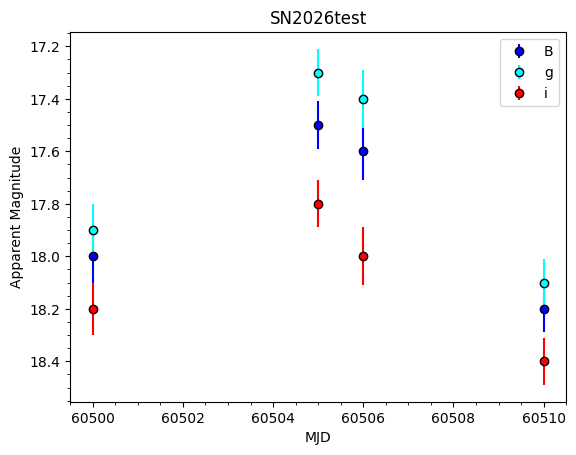

In [3]:
new_sn.plot_data()

### 2. Saving the new SN info

A user likely doesn't want to keep passing in the data and info to the class constructor each time they want to initialize this particular object. To simplify this, the codebase has routines to save the passed-in data as well as any metadata that is provided or calculated. For example, using the `SN.fit_for_max()` method calculates and stores the light curve peak info, which can then be saved to the `CAAT` database file for easy re-initialization later on. Let's walk through that.

First, fit for the light curve peak. Let's check the plot to make sure it's acceptable, then double check that the parameters are added to the `new_sn.info` attribute:

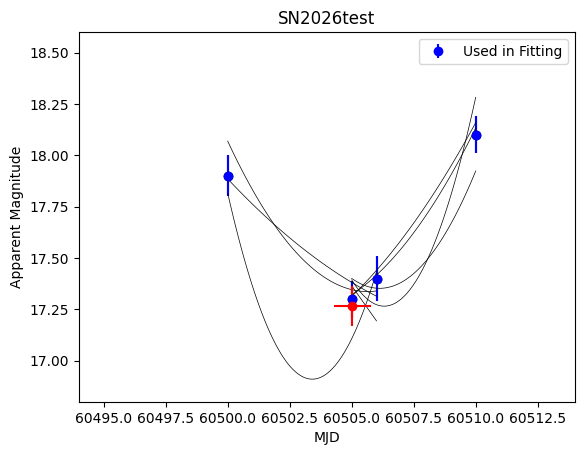

In [4]:
new_sn.fit_for_max(filt="g", plot=True)

In [5]:
# Double check that the light curve peak parameters have been stored after fitting:

print(new_sn.info)

{'ra': 123.456, 'dec': -43.21, 'z': 0.015, 'peak_mjd': 60505.02717171717, 'peak_mag': 17.265359586129193, 'peak_filt': 'g', 'searched': True}


Finally, to make sure that these parameters are saved and accessed each time this `SN` is instantiated in the future, we have to write its information to the `CAAT` database file. 

In this case, this transient is not part of the file already. To add it, we'll use the `SN.write_info_to_caat_file()` method. This will check for the existence of the `SN` by name, and if it does not exist, it will write all the info from `SN.info` to the `CAAT` file in the appropriate order. 

As part of this example, we'll do a dry run and not actually save the data, to avoid polluting the `CAAT` file. To actually overwrite the existing `CAAT` file and save the data in production scenarios, pass `force=True` to the method:

In [6]:
new_sn.write_info_to_caat_file()


### 3. Saving the new SN data

`SN` also has a method to write the passed-in data to a .json file in the appropriate directory, so that it can be loaded and used in future fits. To do so, use the `SN.write_json_data()` method. Note that this method will create new directories to store the `SN` data, if necessary, and will overwrite any existing data files for that object, if they exist. For this example we don't want to actually save anything, so we can specify `dry_run=True`, which will log what the method would do if run "for real."

In [7]:
new_sn.write_json_data(dry_run=True)

INFO:caat.SN:SN directory does not exist. This will make one if `dry_run=False`.
INFO:caat.SN:This will save the data as a new file, or overwrite an existing one. To do so, specify `dry_run=False`.


To use this new `SN` object in future fitting routines, we also need to construct and save its warped datacube. Here we won't save the results, but to do so specify `save=True`:

In [8]:
from caat import DataCube

cube = DataCube(sn=new_sn)
cube.measure_flux_in_filter(save=False)

### 4. Conclusions

Now that the `SN` info and data have been saved in the appropriate places, they can be reloaded and instantiated in the future. This example `SN` is now a full-fledged member of the transient dataset. This allows for dynamic changes to this data repository, enabling new fits of future transients!